## 目标

这个notebook，展示了机器学习基本流程：
1. 了解数据，任务，提交评价标准
2. 简单EDA，探索特征和目标的相关性，做出猜想
   - 进行必要的分类特征编码
   - 清楚特征中缺失值、异常值，多与少，对目标的影响
   - 重要特征之间的相关性
3. 特征工程：这是可选的。为了模型的改善
   - 通过各种方式，产出新的更加重要特征，筛选特征
4. 基线模型：
   - 逻辑回归、随机森林这些几乎不需要做处理的简单模型
5. 改善模型：
   - 使用特征工程等
6. 解释模式：
   - 这一点往往很难做到，我们尽量

## 导入包

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder



In [93]:
plt.rcParams['figure.figsize'] = (5, 3) # 设置默认长宽
# 设置中文字体（Windows常用SimHei，Mac常用Arial Unicode MS）
plt.rcParams['font.sans-serif'] = ['SimHei'] 
# 解决负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False 

In [94]:
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

## 数据读取

In [95]:
os.listdir('data')

['application_test.csv',
 'application_train.csv',
 'bureau.csv',
 'bureau_balance.csv',
 'credit_card_balance.csv',
 'HomeCredit_columns_description.csv',
 'installments_payments.csv',
 'log_regress_model_baseline.csv',
 'POS_CASH_balance.csv',
 'previous_application.csv',
 'random_forest_baseline.csv',
 'sample_submission.csv']

In [96]:
application_train = pd.read_csv('data/application_train.csv')
application_test = pd.read_csv('data/application_test.csv')
bureau = pd.read_csv('data/bureau.csv')
bureau_balance = pd.read_csv('data/bureau_balance.csv')
credit_card_balance = pd.read_csv('data/credit_card_balance.csv')
installments_payments = pd.read_csv('data/installments_payments.csv')
previous_application = pd.read_csv('data/previous_application.csv')
pos_cash_balance = pd.read_csv('data/POS_CASH_balance.csv')


In [97]:
application_train.shape

(307511, 122)

In [98]:
application_train.columns.tolist()

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

## 字段说明


### application_train.csv
`application_train` 共有122个字段，主要分类，转换为还款能力和还款意愿    
- `SK_ID_CURR`: 贷款申请ID
- `TARGET`: 贷款是否违约，1为违约，0为正常还

**个人信息**
- `CODE_GENDER`: 性别
- `DAYS_BIRTH`: 年龄
- `DAYS_REGISTRATION`: 申请注册到现在的天数. 户口本更新时间
- `DAYS_ID_PUBLISH`: 身份证更新时间，身份证更新越频繁，说明个人信息变动越大，风险也越大
- `FLAG_MOBIL`: 是否有手机; `FLAG_EMP_PHONE`: 是否有工作电话; `FLAG_WORK_PHONE`: 是否有工作单位电话; `FLAG_CONT_MOBILE`: 是否有紧急联系人电话; `FLAG_PHONE`: 是否有电话; `FLAG_EMAIL`: 是否有电子邮箱 
  - 都是01值
- `DAYS_LAST_PHONE_CHANGE`: 最后一次更换联系电话的时间，天数表示
  - 联系电话变动越频繁，说明个人信息变动越大，风险也越大
- `NAME_EDUCATION_TYPE` : 教育水平


**车**
- `FLAG_OWN_CAR`: 是否拥有汽车; 
    - 应该是很重要的特征，
- `OWN_CAR_AGE`: 汽车年龄，车龄越大，说明经济状况越差
- 

**房产**
- `FLAG_OWN_REALTY`: 是否拥有房产
- `FONDKAPREMONT_MODE`: 房屋管理模式
- `HOUSETYPE_MODE`: 房屋类型
- `TOTALAREA_MODE`: 房屋总面积
- `WALLSMATERIAL_MODE`: 墙体材料
- `EMERGENCYSTATE_MODE`: 房屋是否危急
- 反映所在建筑的情况：
  - 平均值情况
    - `APARTMENTS_AVG`: g 房屋面积
    - `YEARS_BUILD_AVG`: 房龄，房龄越大，说明经济状况越差
    - `BASEMENTAREA_AVG`: 地下室面积
    - `YEARS_BEGINEXPLUATATION_AVG`: 房屋使用年限
    - `YEAR_BUILD_AVG`: 房屋建成年代
    - `COMMONAREA_AVG`: 公共区域面积
    - `ELEVATORS_AVG`: 电梯数量
    - `ENTRANCES_AVG`: 入口数量
    - `FLOORSMAX_AVG`: 最大楼层数
    - `FLOORSMIN_AVG`: 最小楼层数
    - `LANDAREA_AVG`: 土地面积
    - `LIVINGAPARTMENTS_AVG`: 居住公寓面积
    - `LIVINGAREA_AVG`: 居住面积
    - `NONLIVINGAPARTMENTS_AVG`: 非居住公寓面积
    - `NONLIVINGAREA_AVG`: 非居住面积
  - 众数情况
    - `NONLIVINGAREA_MODE`: 非居住面积
    - `APARTMENTS_MODE`: g 房屋面积
    - `YEARS_BUILD_MODE`: 房龄，房龄越大，说明经济状况越差
    - `BASEMENTAREA_MODE`: 地下室面积
    - `YEARS_BEGINEXPLUATATION_MODE`: 房屋使用年限
    - `YEAR_BUILD_MODE`: 房屋建成年代
    - `COMMONAREA_MODE`: 公共区域面积
    - `ELEVATORS_MODE`: 电梯数量
    - `ENTRANCES_MODE`: 入口数量
    - `FLOORSMAX_MODE`: 最大楼层数        
    - `FLOORSMIN_MODE`: 最小楼层数
    - `LANDAREA_MODE`: 土地面积
    - `LIVINGAPARTMENTS_MODE`: 居住公寓面积
    - `LIVINGAREA_MODE`: 居住面积
    - `NONLIVINGAPARTMENTS_MODE`: 非居住公寓面积
  - 中数情况：
    - ..... 同上

**地区住址**
- `REGION_POPULATION_RELATIVE`: 居住地区人口密度。数值大为大城市
- `REGION_RATING_CLIENT`: 居住地区评级; `REGION_RATING_CLIENT_W_CITY`: 考虑了城市因素的地区评级
  - 大城市风险较低
- `REG_REGION_NOT_LIVE_REGION`: 是否注册地区等于所在地区（省）; 
- `REG_REGION_NOT_WORK_REGION`: 是否注册地区等于工作地区（省）; 
- `LIVE_REGION_NOT_WORK_REGION`: 是否居住地区等于工作地区（省）
- `REG_CITY_NOT_LIVE_CITY`: 是否在登记城市居住; 
- `REG_CITY_NOT_WORK_CITY`: 是否在登记城市工作; 
- `LIVE_CITY_NOT_WORK_CITY`: 是否在居住城市工作
  - 是否跨省流动、跨市流动、异地务工...
  - 如果不在登记地区居住或者工作，说明流动性大，风险也大

**社交圈**
- `OBS_30_CNT_SOCIAL_CIRCLE`: 过去30天内社交圈中有多少人违约; `OBS_60_CNT_SOCIAL_CIRCLE`
- `DEF_30_CNT_SOCIAL_CIRCLE`: 过去30天内社交圈中有多少人违约, 严重逾期; `DEF_60_CNT_SOCIAL_CIRCLE`
  - 社交圈的风险情况，社交圈风险大，个人风险也大

**家庭状况**：
- `NAME_FAMILY_STATUS`: 家庭状况，已婚，单身，离异等
- `CNT_CHILDREN`: 子女数量; `CNT_FAM_MEMBERS`: 家庭成员数量
    - 家庭负担越重，抗风险能力也差

**经济能力**
- `AMT_INCOME_TOTAL`: 年收入
- `AMT_CREDIT`: 贷款金额;
- `AMT_ANNUITY`: 贷款年金，每个月还多少
- `AMT_GOODS_PRICE`: 贷款购买商品的价格
    - 贷款金额和收入的比值，贷款金额和商品价格的比值，能反映借款人的还款压力
- `NAME_INCOME_TYPE`: 收入类型
    - 工资收入，养老金，商业贷款等，不同收入类型的还款能力不同
- `NAME_HOUSING_TYPE`: 住房类型
    - 自有住房，租赁住房等，不同住房类型的还款能力不同

**信用历史，外部评分**
- `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`: 外部其他征信机构对他的评分
  -  这个应该是很重要的
- 征信查询次数:
  - `AMT_REQ_CREDIT_BUREAU_HOUR`: 过去一小时内查询信用局的次数; 
  - `AMT_REQ_CREDIT_BUREAU_DAY`: 过去一天内查询信用局的次数; 
  - `AMT_REQ_CREDIT_BUREAU_WEEK`: 过去一周内查询信用局的次数; 
  - `AMT_REQ_CREDIT_BUREAU_MON`: 过去一个月内查询信用局的次数; 
  - `AMT_REQ_CREDIT_BUREAU_QRT`: 过去一个季度内查询信用局的次数; 
  - `AMT_REQ_CREDIT_BUREAU_YEAR`: 过去一年内查询信用局的次数
    - 查询次数越多，说明借款人越急需资金，风险也越大


**工作情况**
- `DAYS_EMPLOYED`: 工作年限天数
- `OCCUPATION_TYPE`: 职业类型
- `NAME_INCOME_TYPE`: 收入类型
  - 负值表示倒退的天数
- `ORGANIZATION_TYPE`: 工作单位类型
    - 国企，私企，事业单位等，不同单位类型的还款能力

**申请行为**
- `NAME_CONTRACT_TYPE`: 贷款合同类型，现金贷款还是循环贷款。现金贷款直接给全部，循环贷款可以分期还款。
- `NAME_TYPE_SUITE`: 申请时候的陪同人员类型
- `WEEKDAY_APPR_PROCESS_START`: 申请的星期几
- `HOUR_APPR_PROCESS_START`: 申请的时间段
  - 半夜申请和周末申请贷款，可能风险更大
- `FLAG_DOCUMENT_2` 到 `FLAG_DOCUMENT_21`: 提交的证明文件数。 都是01值
  - 提交的身份证件越多，说明资料越齐全，风险也越小



### bureau.csv
`bureau` 共有17个字段，每行为借款人在其他贷款机构的贷历史情况    
- `SK_ID_CURR`: 贷款申请ID. 与`application_train`中的`SK_ID_CURR`对应
- `SK_ID_BUREAU`: 其他贷款机构的贷款ID. 关联`bureau_balance`中的`SK_ID_BUREAU`
- `CREDIT_ACTIVE`: 贷款状态，活跃，结清等
- `CREDIT_CURRENCY`: 贷款币种
- `CREDIT_TYPE`: 贷款类型，信用卡，汽车贷款等
- 日期时间
  - `DAYS_CREDIT`: 贷款申请距今的天数
  - `DAYS_CREDIT_ENDDATE`: 贷款结束距今的天数(到期日)
  - `DAYS_ENDDATE_FACT`: 贷款实际结束距今的天数. 对已经结清的贷款有效
  - `DAYS_CREDIT_UPDATE`: 贷款最后一次更新距今的天数
- 额度，金额, 逾期
  - `CREDIT_DAY_OVERDUE`: 贷款逾期天数
  - `AMT_CREDIT_MAX_OVERDUE`: 这笔贷款历史上最大逾期金额
  - `CNT_CREDIT_PROLONG`: 这笔贷款展期次数. 延长还款期限的次数
  - `AMT_CREDIT_SUM`: 这笔贷款的总授信额度
  - `AMT_CREDIT_SUM_DEBT`: 这笔贷款的未还金额
  - `AMT_CREDIT_SUM_LIMIT`: 这笔贷款的额度上限
  - `AMT_CREDIT_SUM_OVERDUE`: 这笔贷款的逾期金额
  - `AMT_ANNUITY`: 这笔贷款的年金，每个月还多少

### bureau_balance.csv
`bureau_balance` 共有3个字段，记录`bureau`中每笔贷款的每月状态
- `SK_ID_BUREAU`: 其他贷款机构的贷款ID. 关联`bureau`中的`SK_ID_BUREAU`
- `MONTHS_BALANCE`: 记录月份，贷款申请到现在的月数
- `STATUS`: 贷款状态
    - 0: 按时还款
    - 1: 逾期1-30天
    - 2: 逾期31-60天
    - 3: 逾期61-90天
    - 4: 逾期91-120天
    - 5: 逾期120天以上
    - C: 结清
    - X: 无贷款

In [99]:
bureau_balance.head()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


### credit_card_balance.csv
`credit_card_balance` 共有23个字段，记录信用卡每月的账单
- `SK_ID_CURR`: 贷款申请ID. 与`application_train`中的`SK_ID_CURR`对应
- `SK_ID_PREV`: 贷款ID. 关联`previous_application`中的`SK_ID_PREV`
- `MONTHS_BALANCE`: 记录月份，贷款申请到现在的月数
- `NAME_CONTRACT_STATUS`: 信用卡合同状态
    - Active: 活跃
    - Closed: 关闭
    - Sold: 出售
    - Demand: 需求
- `AMT_BALANCE`: 账单余额
- `AMT_CREDIT_LIMIT_ACTUAL`: 实际信用额度
- `AMT_DRAWINGS_ATM_CURRENT`: 目前ATM取现额度
- `AMT_DRAWINGS_CURRENT`: 目前取现额度
- `AMT_DRAWINGS_OTHER_CURRENT`: 目前其他取现额度
- `AMT_DRAWINGS_POS_CURRENT`: 目前POS取现额度
- `AMT_INST_MIN_REGULARITY`: 最低还款金额
- `AMT_PAYMENT_CURRENT`: 本期还款金额
- `AMT_PAYMENT_TOTAL_CURRENT`: 本期应还金额
- `AMT_RECEIVABLE_PRINCIPAL`: 应收本金
- `AMT_RECIVABLE`: 应收总额
- `AMT_TOTAL_RECEIVABLE`: 应收总额
- `CNT_DRAWINGS_ATM_CURRENT`: 目前ATM取现次数
- `CNT_DRAWINGS_CURRENT`: 目前取现次数
- `CNT_DRAWINGS_OTHER_CURRENT`: 目前其他取现次数
- `CNT_DRAWINGS_POS_CURRENT`: 目前POS取现次数
- `CNT_INSTALMENT_MATURE_CUM`: 累计分期付款次数
- `SK_DPD`: 逾期天数
- `SK_DPD_DEF`: 逾期天数，严重逾期

yy
yyyY

In [100]:
credit_card_balance.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'AMT_BALANCE',
       'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT',
       'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT',
       'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY',
       'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT',
       'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE',
       'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT',
       'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT',
       'CNT_INSTALMENT_MATURE_CUM', 'NAME_CONTRACT_STATUS', 'SK_DPD',
       'SK_DPD_DEF'],
      dtype='str')

### previous_application.csv
记录了借款人之前在home credit机构的贷款申请情况，共有37个字段
- `SK_ID_CURR`: 贷款申请ID. 与`application_train`中的`SK_ID_CURR`对应
- `SK_ID_PREV`: 贷款ID. 关联`credit_card_balance`中的`SK_ID_PREV` 。 表示之前的贷款ID

Y

In [101]:
previous_application.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY',
       'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE',
       'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
       'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY',
       'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY',
       'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE',
       'NAME_CONTRACT_STATUS', 'DAYS_DECISION', 'NAME_PAYMENT_TYPE',
       'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE',
       'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE',
       'CHANNEL_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY',
       'CNT_PAYMENT', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION',
       'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION',
       'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL'],
      dtype='str')

### installments_payments.csv

### pos_cash_balance.csv

### metric: ROC


## Exploratory Data Analysis
- 发现有趣的现象和特征

### Distribution of TARGET

In [102]:
application_train['TARGET'].value_counts()[0] /application_train['TARGET'].value_counts().sum()

np.float64(0.9192711805431351)

<Axes: xlabel='TARGET'>

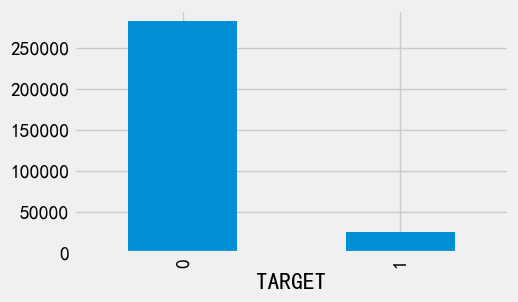

In [103]:
application_train['TARGET'].value_counts().plot(kind='bar')

可以看到，这是一个不平衡的分类，违约的样本只占大约8%

### Missing Values
- 看看哪些字段缺失值较多
- 后续 大部分模型都需要处理缺失值

In [104]:
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * mis_val / len(df)
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table_ren_columns = mis_val_table.rename(
        columns={0: 'Missing Values', 1: '% of Total Values'}
        )
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns['Missing Values'] > 0
    ]
    mis_val_table_ren_columns = mis_val_table_ren_columns.sort_values(
        '% of Total Values', ascending=False
    ).round(1)
    print("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"
          "There are " + str(mis_val_table_ren_columns[mis_val_table_ren_columns['Missing Values'] > 0].shape[0]) +
          " columns that have missing values.")
    return mis_val_table_ren_columns

In [105]:
missing_values_table(application_train).head(10)

Your selected dataframe has 122 columns.
There are 67 columns that have missing values.


,Missing Values,% of Total Values
COMMONAREA_MEDI,214865,69.9
COMMONAREA_MODE,214865,69.9
COMMONAREA_AVG,214865,69.9
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_MEDI,213514,69.4
NONLIVINGAPARTMENTS_AVG,213514,69.4
FONDKAPREMONT_MODE,210295,68.4
LIVINGAPARTMENTS_AVG,210199,68.4
LIVINGAPARTMENTS_MEDI,210199,68.4
LIVINGAPARTMENTS_MODE,210199,68.4


### column types
- int64, float64 数值特征
- object 分类特征

In [106]:
application_train.dtypes.value_counts()

float64    65
int64      41
str        16
Name: count, dtype: int64

In [107]:
application_train.select_dtypes('object').apply(pd.Series.nunique, axis=0)

C:\Users\63517\AppData\Local\Temp\ipykernel_20680\3850001950.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  application_train.select_dtypes('object').apply(pd.Series.nunique, axis=0)


NAME_CONTRACT_TYPE             2
CODE_GENDER                    3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
EMERGENCYSTATE_MODE            2
dtype: int64

大多数类别变量都有比较少的分类值

### Encoding categorical variable
- 大部分模型都需要预处理这些分类特征，编码为数字
  - `label encoding` 和 `one-hot encoding`
- 对二分类特征使用`label encoding`
- 对多酚类特征使用`one-hot encoding`
  - 也可以使用pandas `get_dummies(df)`  更方便

In [108]:
le = LabelEncoder()
le_cnt = 0

for col in application_train:
    if application_train[col].dtype == 'object':
        if len(application_train[col].unique()) <= 2:
            # 二分类特征
            le.fit(application_train[col])
            application_train[col] = le.transform(application_train[col])
            application_test[col] = le.transform(application_test[col])
            le_cnt += 1
print('%d columns are label encoded.' % le_cnt)


0 columns are label encoded.


In [109]:
application_train = pd.get_dummies(application_train)
application_test = pd.get_dummies(application_test)
print(f"Training Features shape with one-hot : {application_train.shape}")
print(f"Testing Features shape with one-hot : {application_test.shape}")

Training Features shape with one-hot : (307511, 246)
Testing Features shape with one-hot : (48744, 242)


- 这里特征数量翻了一倍！
- 特征数量训练和测试也不匹配

### align train and test features
- 对齐训练数据和测试数据特征，因为onehot
- 采取inner交集的方式

In [110]:
# 保留下拉，inner会除掉
train_labels = application_train['TARGET'] 

application_train, application_test = application_train.align(application_test, join='inner', axis=1)

In [111]:
application_train['TARGET'] = train_labels

In [112]:
print('Training Features shape: ', application_train.shape)
print('Testing Features shape: ', application_test.shape)

Training Features shape:  (307511, 243)
Testing Features shape:  (48744, 242)


### Anomalies 异常数据处理
- 一些异常的数据。 通过`describe`查看统计量筛选

In [113]:
(application_train['DAYS_BIRTH'] / -365).describe()

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: DAYS_BIRTH, dtype: float64

这看起来没什么异常


In [114]:
application_train['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

这明显不对，最大值是+36万天。我们通过分布频次直方图看一下

Text(0.5, 0, 'Days employed')

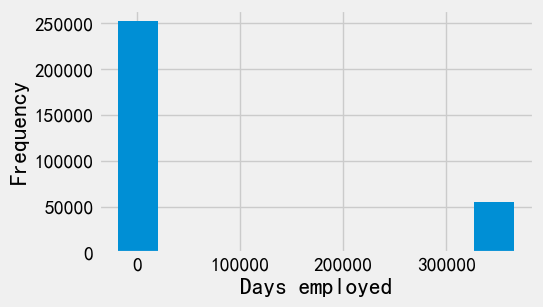

In [115]:
application_train['DAYS_EMPLOYED'].plot.hist()
plt.xlabel('Days employed')

我们可以看到，
- 右侧还是有很多人的异常数据集中分布
- 由于max值很异常，导致左边的正常数据缩成一团



需要对这些异常数据的人观察，看他们target如何

In [116]:
anom = application_train[application_train['DAYS_EMPLOYED'] == 365243]
non_anom = application_train[application_train['DAYS_EMPLOYED'] != 365243]
print(f'The non-anom people 违约 on avg:{non_anom['TARGET'].mean() * 100:.2f}%')
print(f'The anom people 违约 on avg:{anom['TARGET'].mean() * 100:.2f}%')
print(f'There are {len(anom)} anomalous days of employment')


The non-anom people 违约 on avg:8.66%
The anom people 违约 on avg:5.40%
There are 55374 anomalous days of employment


这样看来，异常这些的人 违约率更低！ 😊
- 不能随便删除这些行！
- 用空缺 `np.nan`代替，是个**安全**的方法

<Axes: ylabel='Frequency'>

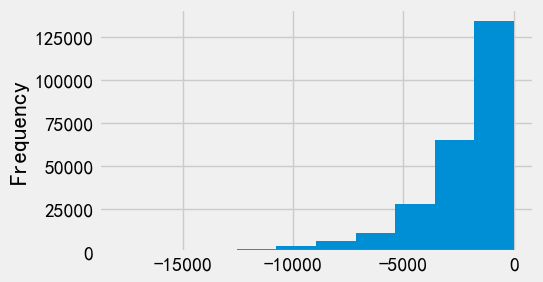

In [117]:
# 我们还创建了一个辅助的列 标识这个字段异常的行
application_train['DAYS_EMPLOYED_ANOM'] = application_train["DAYS_EMPLOYED"] == 365243

application_train['DAYS_EMPLOYED'] = application_train['DAYS_EMPLOYED'].replace({365243: np.nan})
application_train['DAYS_EMPLOYED'].plot.hist()

现在看起来好多了呐😊，此外，我们创建了一个列，表明这个字段最初是异常的。（后续可能会进行均值等代替）

对train的操作，也做到test上

<Axes: ylabel='Frequency'>

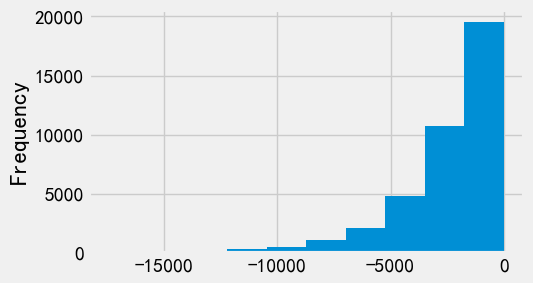

In [118]:
application_test['DAYS_EMPLOYED_ANOM'] = application_test["DAYS_EMPLOYED"] == 365243

application_test['DAYS_EMPLOYED'] = application_test['DAYS_EMPLOYED'].replace({365243: np.nan})
application_test['DAYS_EMPLOYED'].plot.hist()

### correlations
- 类别特征处理后，现在都是数值列了，可以计算与target相关性
- `df.corr()` 提供了快速的方法，计算相关系数

In [119]:
correlations = application_train.corr()

In [120]:
correlations = correlations['TARGET'].sort_values()

In [121]:
print('Top 5 positive features: \n', correlations.tail(5))

Top 5 positive features: 
 REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_EMPLOYED                  0.074958
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, dtype: float64


In [122]:
print('TOP 5 negative features: \n', correlations.head(5))

TOP 5 negative features: 
 EXT_SOURCE_3                           -0.178919
EXT_SOURCE_2                           -0.160472
EXT_SOURCE_1                           -0.155317
NAME_EDUCATION_TYPE_Higher education   -0.056593
CODE_GENDER_F                          -0.054704
Name: TARGET, dtype: float64


#### DAYS_BIRTH 年龄因素

最正相关的是`DAYS_BIRTH` 和`DAYS_EMPLOYED`
- 实际意义，因为是负值，所以实际是负相关的。！
  - 也就是说，年龄增长，违约风险越低

可以做绝对值看看

In [123]:
application_train['DAYS_BIRTH'] = abs(application_train['DAYS_BIRTH'])

In [124]:
application_train['DAYS_BIRTH'].corr(application_train['TARGET'])

np.float64(-0.07823930830982709)

我们可以认为，年龄越大，违约风险越低吗？ 

年龄分布直方图

Text(0.5, 0, 'AGE')

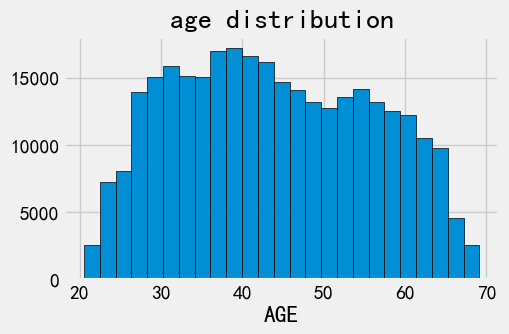

In [125]:
plt.style.use('fivethirtyeight')
plt.hist(application_train['DAYS_BIRTH'] / 365, bins=25, edgecolor='k')
plt.title('age distribution')
plt.xlabel('AGE')

年龄分布是合理的。 我们看下分开target的平滑直方图

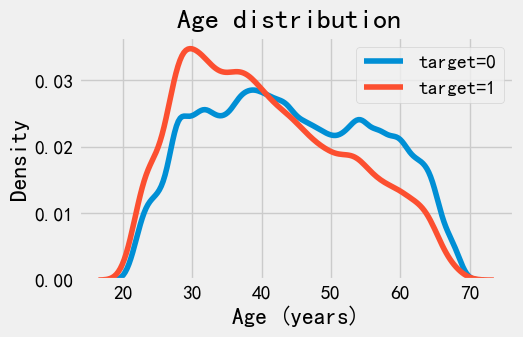

In [126]:
sns.kdeplot(
    application_train.loc[application_train['TARGET']==0, 'DAYS_BIRTH'] / 365, 
    label = 'target=0'
)
sns.kdeplot(
    application_train.loc[application_train['TARGET']==1, 'DAYS_BIRTH'] / 365, 
    label = 'target=1'
)
plt.xlabel('Age (years)')
plt.title('Age distribution ')
plt.legend()

可以看到， target=1的曲线，明显倾向于年轻人。

换个角度，从年龄段看看，看看每个年龄段平均违约率。 条形图


In [127]:
age_data = application_train[['TARGET', 'DAYS_BIRTH']]

In [128]:
age_data['YEARS_BIRTH'] = age_data['DAYS_BIRTH'] / 365

In [129]:
# bin age data
age_data['YEARS_BINNED'] = pd.cut(
    age_data['YEARS_BIRTH'],
    bins = np.linspace(20, 70, num=11),
)

In [130]:
age_groups = age_data.groupby('YEARS_BINNED').mean()

Text(0.5, 1.0, '违约概率年龄分布')

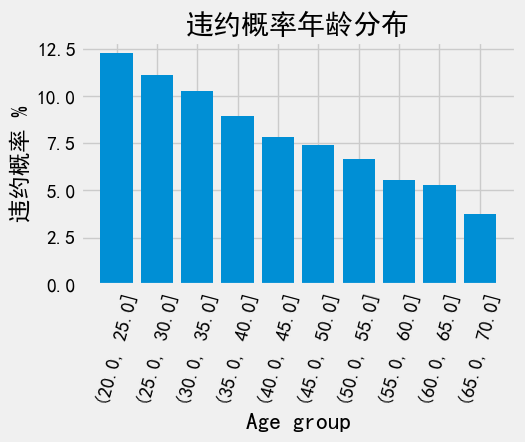

In [131]:
plt.bar(age_groups.index.astype(str), 100 * age_groups['TARGET'])
plt.xticks(rotation=75)
plt.xlabel('Age group')
plt.ylabel('违约概率 %')
plt.title('违约概率年龄分布')

确实是这样，越年轻的客户更容易违约

#### Exterior Sources
`EXIT_SOURCE_1..3`是最负相关的三个特征

In [132]:
ext_data = application_train[['TARGET', 'EXT_SOURCE_1',  'EXT_SOURCE_2', 'EXT_SOURCE_3']]

In [133]:
ext_data_corrs = ext_data.corr()
ext_data_corrs

,TARGET,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
TARGET,1.000000,-0.155317,-0.160472,-0.178919
EXT_SOURCE_1,-0.155317,1.000000,0.213982,0.186846
EXT_SOURCE_2,-0.160472,0.213982,1.000000,0.109167
EXT_SOURCE_3,-0.178919,0.186846,0.109167,1.000000


Text(0.5, 1.0, 'correlations map')

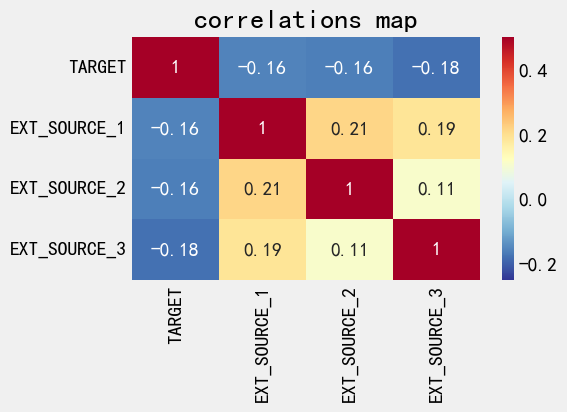

In [134]:
sns.heatmap(
    ext_data_corrs,
    cmap = plt.cm.RdYlBu_r,
    vmin = -0.25,
    vmax = 0.5,
    annot = True
)
plt.title('correlations map')

观察下不同target下的分布

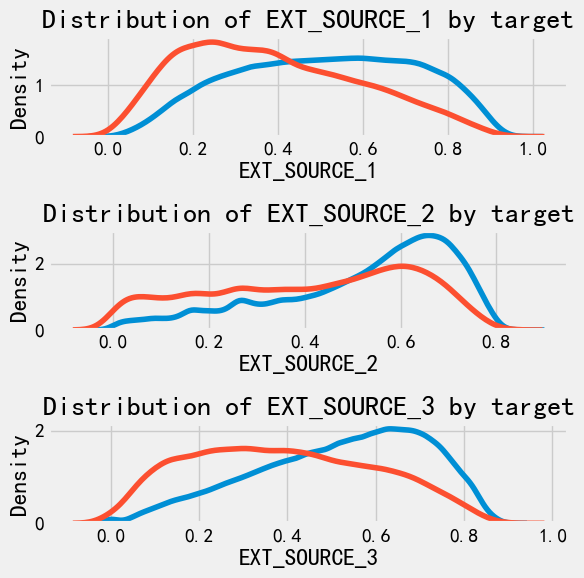

In [135]:
plt.figure(figsize = (6,6))
for i, source in enumerate(['EXT_SOURCE_1',  'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    plt.subplot(3, 1 , i + 1)
    sns.kdeplot(
        application_train.loc[application_train['TARGET'] == 0, source],
        label = 'target = 0'
    )
    sns.kdeplot(
        application_train.loc[application_train['TARGET'] == 1, source],
        label = 'target = 1'
    )
    plt.title(f'Distribution of {source} by target')
plt.tight_layout()


可以看到，相对而言,`EXIT_SOURCE_3`和`EXIT_SOURCE_1`可能对target有比较强的关联

### pairs plot
- 我们找到了`DAYS_BIRTH` `EXIT_SOUCE_` 与目标最相关的特征，但对于这两特征之间，我们还要探索
- 通过pairs plot 可以探索 两两变量的关系 和 单变量的分布

In [136]:
plot_data = application_train[['TARGET', 'DAYS_BIRTH', 'EXT_SOURCE_3', 'EXT_SOURCE_1']]

In [137]:
plot_data = plot_data.dropna().loc[:1000, :]

In [138]:
def plot_crr(x, y, **kwargs):
    r = np.corrcoef(x, y)[0][1]
    ax = plt.gca() # 获取当前坐标轴
    ax.annotate(f"r = {r:.2f}", xy=(0.5, 0.5))

C:\Users\63517\AppData\Local\Temp\ipykernel_20680\2750256857.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


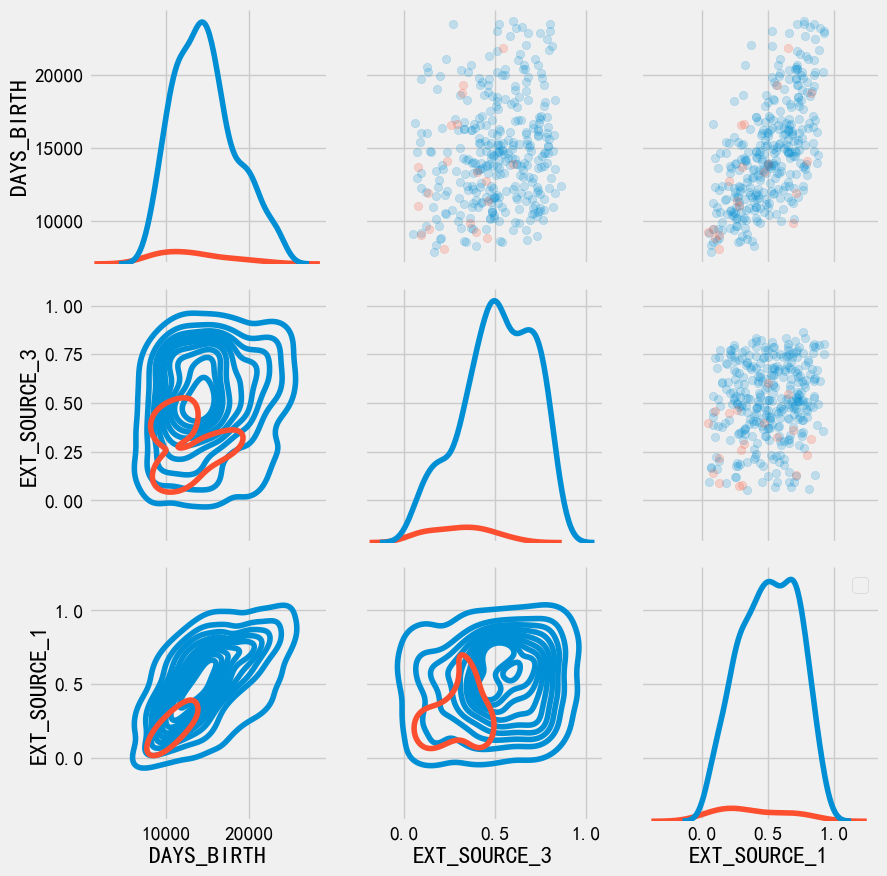

In [139]:
grid = sns.PairGrid(data = plot_data, height = 3, diag_sharey=False,
                    hue = 'TARGET', 
                    vars = [x for x in list(plot_data.columns) if x != 'TARGET'])

grid.map_upper(plt.scatter, alpha = 0.2)
grid.map_diag(sns.kdeplot)
grid.map_lower(sns.kdeplot);
plt.legend()

注意：由于TARGET分布是不均匀的，所以这里看起来怪怪的

## 特征工程
- 胜负关键就来自于特征工程，  获胜模型往往是梯度提升变体
- 特征工程比模型构建和超参数调优具有更高的投资回报率。
- 特征工程：就是 构建新特征、选择特征

简单的特征构造方法：
- Polynomial features 多项式特征
- Domain knowledge features 领域知识特性

### Polynomial Features 多项式特征


In [140]:
poly_features = application_train[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3', 'DAYS_BIRTH']]
poly_features_test = application_test[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3', 'DAYS_BIRTH']]
poly_target = application_train['TARGET']

In [141]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = 'median')

In [142]:
poly_features = imputer.fit_transform(poly_features)
poly_features_test = imputer.fit_transform(poly_features_test)


In [143]:
from sklearn.preprocessing import  PolynomialFeatures
poly_transformer = PolynomialFeatures(degree=3)

In [144]:

poly_transformer.fit(poly_features)

,degree,3
,interaction_only,False
,include_bias,True
,order,'C'


In [145]:
poly_features = poly_transformer.transform(poly_features)
poly_features_test = poly_transformer.transform(poly_features_test)
print('Polynomial features shape: ', poly_features.shape)

Polynomial features shape:  (307511, 35)


In [146]:
poly_transformer.get_feature_names_out()

array(['1', 'x0', 'x1', 'x2', 'x3', 'x0^2', 'x0 x1', 'x0 x2', 'x0 x3',
       'x1^2', 'x1 x2', 'x1 x3', 'x2^2', 'x2 x3', 'x3^2', 'x0^3',
       'x0^2 x1', 'x0^2 x2', 'x0^2 x3', 'x0 x1^2', 'x0 x1 x2', 'x0 x1 x3',
       'x0 x2^2', 'x0 x2 x3', 'x0 x3^2', 'x1^3', 'x1^2 x2', 'x1^2 x3',
       'x1 x2^2', 'x1 x2 x3', 'x1 x3^2', 'x2^3', 'x2^2 x3', 'x2 x3^2',
       'x3^3'], dtype=object)

现在我们 看下生成的新特征与target关系如何？

In [147]:
poly_features = pd.DataFrame(
    poly_features,
    columns = poly_transformer.get_feature_names_out(['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3', 'DAYS_BIRTH'])
)
poly_features

,1,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH,EXT_SOURCE_1^2,EXT_SOURCE_1 EXT_SOURCE_2,EXT_SOURCE_1 EXT_SOURCE_3,EXT_SOURCE_1 DAYS_BIRTH,EXT_SOURCE_2^2,EXT_SOURCE_2 EXT_SOURCE_3,EXT_SOURCE_2 DAYS_BIRTH,EXT_SOURCE_3^2,EXT_SOURCE_3 DAYS_BIRTH,DAYS_BIRTH^2,EXT_SOURCE_1^3,EXT_SOURCE_1^2 EXT_SOURCE_2,EXT_SOURCE_1^2 EXT_SOURCE_3,EXT_SOURCE_1^2 DAYS_BIRTH,EXT_SOURCE_1 EXT_SOURCE_2^2,EXT_SOURCE_1 EXT_SOURCE_2 EXT_SOURCE_3,EXT_SOURCE_1 EXT_SOURCE_2 DAYS_BIRTH,EXT_SOURCE_1 EXT_SOURCE_3^2,EXT_SOURCE_1 EXT_SOURCE_3 DAYS_BIRTH,EXT_SOURCE_1 DAYS_BIRTH^2,EXT_SOURCE_2^3,EXT_SOURCE_2^2 EXT_SOURCE_3,EXT_SOURCE_2^2 DAYS_BIRTH,EXT_SOURCE_2 EXT_SOURCE_3^2,EXT_SOURCE_2 EXT_SOURCE_3 DAYS_BIRTH,EXT_SOURCE_2 DAYS_BIRTH^2,EXT_SOURCE_3^3,EXT_SOURCE_3^2 DAYS_BIRTH,EXT_SOURCE_3 DAYS_BIRTH^2,DAYS_BIRTH^3
0,1.0,0.083037,0.262949,0.139376,9461.0,0.006895,0.021834,0.011573,785.612748,0.069142,0.036649,2487.756636,0.019426,1318.634256,89510521.0,0.000573,0.001813,0.000961,65.234900,0.005741,0.003043,206.575767,0.001613,109.495390,7.432682e+06,0.018181,0.009637,654.152107,0.005108,346.733022,2.353667e+07,0.002707,183.785678,1.247560e+07,8.468590e+11
1,1.0,0.311267,0.622246,0.535276,16765.0,0.096887,0.193685,0.166614,5218.396475,0.387190,0.333073,10431.950422,0.286521,8973.906339,281065225.0,0.030158,0.060288,0.051861,1624.316241,0.120520,0.103675,3247.125160,0.089185,2793.283699,8.748642e+07,0.240927,0.207254,6491.237078,0.178286,5583.975307,1.748916e+08,0.153368,4803.518937,1.504475e+08,4.712058e+12
2,1.0,0.505998,0.555912,0.729567,19046.0,0.256034,0.281290,0.369159,9637.236584,0.309038,0.405575,10587.901540,0.532268,13895.327191,362750116.0,0.129553,0.142332,0.186794,4876.421768,0.156373,0.205220,5357.456268,0.269326,7031.006802,1.835508e+08,0.171798,0.225464,5885.942404,0.295894,7724.580288,2.016572e+08,0.388325,10137.567875,2.646504e+08,6.908939e+12
3,1.0,0.505998,0.650442,0.535276,19005.0,0.256034,0.329122,0.270849,9616.490669,0.423074,0.348166,12361.644326,0.286521,10172.925140,361190025.0,0.129553,0.166535,0.137049,4865.924377,0.214075,0.176171,6254.966447,0.144979,5147.479068,1.827614e+08,0.275185,0.226462,8040.528832,0.186365,6616.894625,2.349331e+08,0.153368,5445.325225,1.933364e+08,6.864416e+12
4,1.0,0.505998,0.322738,0.535276,19932.0,0.256034,0.163305,0.270849,10085.550751,0.104160,0.172754,6432.819536,0.286521,10669.126224,397284624.0,0.129553,0.082632,0.137049,5103.267808,0.052705,0.087413,3254.993372,0.144979,5398.555790,2.010252e+08,0.033616,0.055754,2076.117157,0.092471,3443.335521,1.282190e+08,0.153368,5710.929881,2.126570e+08,7.918677e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,1.0,0.145570,0.681632,0.535276,9327.0,0.021191,0.099226,0.077920,1357.735625,0.464623,0.364862,6357.585111,0.286521,4992.521588,86992929.0,0.003085,0.014444,0.011343,197.646191,0.067635,0.053113,925.476551,0.041709,726.763635,1.266360e+07,0.316702,0.248701,4333.535804,0.195302,3403.064320,5.929720e+07,0.153368,2672.378236,4.656525e+07,8.113830e+11
307507,1.0,0.505998,0.115992,0.535276,20775.0,0.256034,0.058692,0.270849,10512.107006,0.013454,0.062088,2409.735313,0.286521,11120.364104,431600625.0,0.129553,0.029698,0.137049,5319.104390,0.006808,0.031416,1219.321081,0.144979,5626.881223,2.183890e+08,0.001561,0.007202,279.510194,0.033234,1289.874083,5.006225e+07,0.153368,5952.466801,2.310256e+08,8.966503e+12
307508,1.0,0.744026,0.535722,0.218859,14966.0,0.553575,0.398591,0.162837,11135.099105,0.286998,0.117248,8017.611736,0.047899,3275.445025,223981156.0,0.411875,0.296562,0.121155,8284.807703,0.213534,0.087235,5965.314798,0.035638,2437.017571,1.666479e+08,0.153751,0.062812,4295.209004,0.025661,1754.727146,1.199916e+08,0.010483,716.860892,4.902031e+07,3.352102e+12
307509,1.0,0.505998,0.514163,0.661024,11961.0,0.256034,0.260165,0.334477,6052.241247,0.264363,0.339874,6149.901495,0.436952,7906.502552,143065521.0,0.129553,0.131643,0.169244,3062.421546,0.133767,0.

In [148]:
poly_features['TARGET'] = poly_target
poly_corrs = poly_features.corr()['TARGET'].sort_values()
print('TOP 5 positive feature\n', poly_corrs.head(5))
print('TOP 5 negetive feature\n', poly_corrs.tail(5))


TOP 5 positive feature
 EXT_SOURCE_2 EXT_SOURCE_3                -0.193939
EXT_SOURCE_1 EXT_SOURCE_2 EXT_SOURCE_3   -0.189605
EXT_SOURCE_2 EXT_SOURCE_3 DAYS_BIRTH     -0.181283
EXT_SOURCE_2^2 EXT_SOURCE_3              -0.176428
EXT_SOURCE_2 EXT_SOURCE_3^2              -0.172282
Name: TARGET, dtype: float64
TOP 5 negetive feature
 DAYS_BIRTH     -0.078239
DAYS_BIRTH^2   -0.076672
DAYS_BIRTH^3   -0.074273
TARGET          1.000000
1                    NaN
Name: TARGET, dtype: float64


可以看到，一些新的特征与target 相关性大于原特征，  我们可以试着采用他

In [149]:
poly_features_test = pd.DataFrame(
    poly_features_test,
    columns = poly_transformer.get_feature_names_out(['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3', 'DAYS_BIRTH'])
)
poly_features_test

,1,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH,EXT_SOURCE_1^2,EXT_SOURCE_1 EXT_SOURCE_2,EXT_SOURCE_1 EXT_SOURCE_3,EXT_SOURCE_1 DAYS_BIRTH,EXT_SOURCE_2^2,EXT_SOURCE_2 EXT_SOURCE_3,EXT_SOURCE_2 DAYS_BIRTH,EXT_SOURCE_3^2,EXT_SOURCE_3 DAYS_BIRTH,DAYS_BIRTH^2,EXT_SOURCE_1^3,EXT_SOURCE_1^2 EXT_SOURCE_2,EXT_SOURCE_1^2 EXT_SOURCE_3,EXT_SOURCE_1^2 DAYS_BIRTH,EXT_SOURCE_1 EXT_SOURCE_2^2,EXT_SOURCE_1 EXT_SOURCE_2 EXT_SOURCE_3,EXT_SOURCE_1 EXT_SOURCE_2 DAYS_BIRTH,EXT_SOURCE_1 EXT_SOURCE_3^2,EXT_SOURCE_1 EXT_SOURCE_3 DAYS_BIRTH,EXT_SOURCE_1 DAYS_BIRTH^2,EXT_SOURCE_2^3,EXT_SOURCE_2^2 EXT_SOURCE_3,EXT_SOURCE_2^2 DAYS_BIRTH,EXT_SOURCE_2 EXT_SOURCE_3^2,EXT_SOURCE_2 EXT_SOURCE_3 DAYS_BIRTH,EXT_SOURCE_2 DAYS_BIRTH^2,EXT_SOURCE_3^3,EXT_SOURCE_3^2 DAYS_BIRTH,EXT_SOURCE_3 DAYS_BIRTH^2,DAYS_BIRTH^3
0,1.0,0.752614,0.789654,0.159520,-19241.0,0.566429,0.594305,0.120057,-14481.055414,0.623554,0.125965,-15193.739370,0.025446,-3069.315478,370216081.0,0.426302,0.447283,0.090356,-10898.652144,0.469296,0.094803,-11435.028416,0.019151,-2310.011305,2.786300e+08,0.492392,0.099469,-11997.802403,0.020094,-2423.698322,2.923427e+08,0.004059,-489.615795,5.905670e+07,-7.123328e+12
1,1.0,0.564990,0.291656,0.432962,-18064.0,0.319214,0.164783,0.244619,-10205.983005,0.085063,0.126276,-5268.465530,0.187456,-7821.019554,326308096.0,0.180353,0.093101,0.138207,-5766.280398,0.048060,0.071345,-2976.631403,0.105911,-4418.799416,1.843609e+08,0.024809,0.036829,-1536.577117,0.054673,-2281.043619,9.516956e+07,0.081161,-3386.201665,1.412789e+08,-5.894429e+12
2,1.0,0.506771,0.699787,0.610991,-20038.0,0.256817,0.354632,0.309633,-10154.682538,0.489702,0.427564,-14022.328504,0.373310,-12243.044232,401521444.0,0.130148,0.179717,0.156913,-5146.101280,0.248167,0.216677,-7106.113105,0.189183,-6204.422970,2.034795e+08,0.342687,0.299203,-9812.640816,0.261238,-8567.521115,2.809794e+08,0.228089,-7480.393855,2.453261e+08,-8.045687e+12
3,1.0,0.525734,0.509677,0.612704,-13976.0,0.276396,0.267955,0.322119,-7347.658072,0.259771,0.312281,-7123.246872,0.375406,-8563.154516,195328576.0,0.145311,0.140873,0.169349,-3862.913505,0.136570,0.164177,-3744.932912,0.197364,-4501.941285,1.026909e+08,0.132399,0.159163,-3630.555667,0.191336,-4364.443591,9.955450e+07,0.230013,-5246.681115,1.196786e+08,-2.729912e+12
4,1.0,0.202145,0.425687,0.519097,-13040.0,0.040863,0.086051,0.104933,-2635.970697,0.181210,0.220973,-5550.962315,0.269462,-6769.029290,170041600.0,0.008260,0.017395,0.021212,-532.848276,0.036631,0.044669,-1122.099233,0.054470,-1368.325372,3.437306e+07,0.077139,0.094065,-2362.974127,0.114707,-2881.489762,7.238455e+07,0.139877,-3513.785087,8.826814e+07,-2.217342e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48739,1.0,0.506771,0.648575,0.643026,-19970.0,0.256817,0.328679,0.325867,-10120.222092,0.420649,0.417050,-12952.040912,0.413482,-12841.220515,398800900.0,0.130148,0.166565,0.165140,-5128.637716,0.213173,0.211349,-6563.722112,0.209541,-6507.561520,2.021008e+08,0.272823,0.270488,-8400.368742,0.268174,-8328.493414,2.586523e+08,0.265879,-8257.233066,2.564392e+08,-7.964054e+12
48740,1.0,0.506771,0.684596,0.519097,-11186.0,0.256817,0.346933,0.263064,-5668.743331,0.468671,0.355372,-7657.886652,0.269462,-5806.622825,125126596.0,0.130148,0.175816,0.133313,-2872.756209,0.237509,0.180092,-3880.796879,0.136556,-2942.629574,6.341056e+07,0.320850,0.243286,-5242.555692,0.184473,-3975.188577,8.566112e+07,0.139877,-3014.202453,6.495288e+07,-1.399666e+12
48741,1.0,0.733503,0.632770,0.283712,-15922.0,0.538027,0.464139,0.208104,-11678.842724,0.400397,0.179524,-10074.956787,0.080492,-4517.260595,253510084.0,0.394645,0.340447,0.152645,-8566.472012,0.293693,0.131682,-7390.016063,0.059041,-3313.426456,1.859505e+08,0.253359,0.113597,-6375.125880,0.050933,-2858.384957,1.604135e+08,0.022837,-1281.600508,7.192382e+07,-4.036388e+12
48742,1.0,0.373090,0.445701,0.595456,-13968.0,0.139196,0.166287,0.222159,-5211.322249,0.198649,

In [150]:
poly_features['SK_ID_CURR'] = application_train['SK_ID_CURR']
application_train_poly = application_train.merge(poly_features, on = 'SK_ID_CURR', how='left')

poly_features_test['SK_ID_CURR'] = application_test['SK_ID_CURR']
application_test_poly = application_test.merge(poly_features_test, on = 'SK_ID_CURR', how='left')


In [151]:
print(application_train_poly.shape, application_test_poly.shape)

(307511, 280) (48744, 278)


对齐一下特征

In [152]:
application_train_poly, application_test_poly = application_train_poly.align(
    application_test_poly, join='inner',axis = 1
)
print(application_train_poly.shape, application_test_poly.shape)

(307511, 278) (48744, 278)


### Domain Knowledge Features
- 领域知识：就是利用对业务的理解，手动构造一些特征。
  - 比如信贷：原始数据：月收入、月还款额。领域知识特征：“负债率”（月还款 / 月收入）。

我们得到了一些领域知识特征：
- CREDIT_INCOME_PERCENT ： 贷款金额 与 收入 百分比
- ANNUITY_INCOME_PERCENT： 月还款 与 收入百分比
- CREDIT_TERM： 支付期数
- DAYS_EMPLOYED_PERCENT： 工作天数 与 年龄 百分比

In [153]:
print(application_train.shape)

(307511, 244)


In [154]:
application_train_domain = application_train.copy()
application_test_domain = application_test.copy()

In [155]:
application_train_domain['CREDIT_INCOME_PERCENT'] = application_train_domain['AMT_CREDIT']/application_train_domain['AMT_INCOME_TOTAL']
application_train_domain['ANNUITY_INCOME_PERCENT'] = application_train_domain['AMT_ANNUITY'] / application_train_domain['AMT_INCOME_TOTAL']
application_train_domain['CREDIT_TERM'] = application_train_domain['AMT_ANNUITY'] / application_train_domain['AMT_CREDIT']
application_train_domain['DAYS_EMPLOYED_PERCENT'] = application_train_domain['DAYS_EMPLOYED'] / application_train_domain['DAYS_BIRTH']

In [156]:
application_test_domain['CREDIT_INCOME_PERCENT'] = application_test_domain['AMT_CREDIT']/application_test_domain['AMT_INCOME_TOTAL']
application_test_domain['ANNUITY_INCOME_PERCENT'] = application_test_domain['AMT_ANNUITY'] / application_test_domain['AMT_INCOME_TOTAL']
application_test_domain['CREDIT_TERM'] = application_test_domain['AMT_ANNUITY'] / application_train_domain['AMT_CREDIT']
application_test_domain['DAYS_EMPLOYED_PERCENT'] = application_test_domain['DAYS_EMPLOYED'] / application_test_domain['DAYS_BIRTH']

我们来看下这几个新变量和目标的相关性

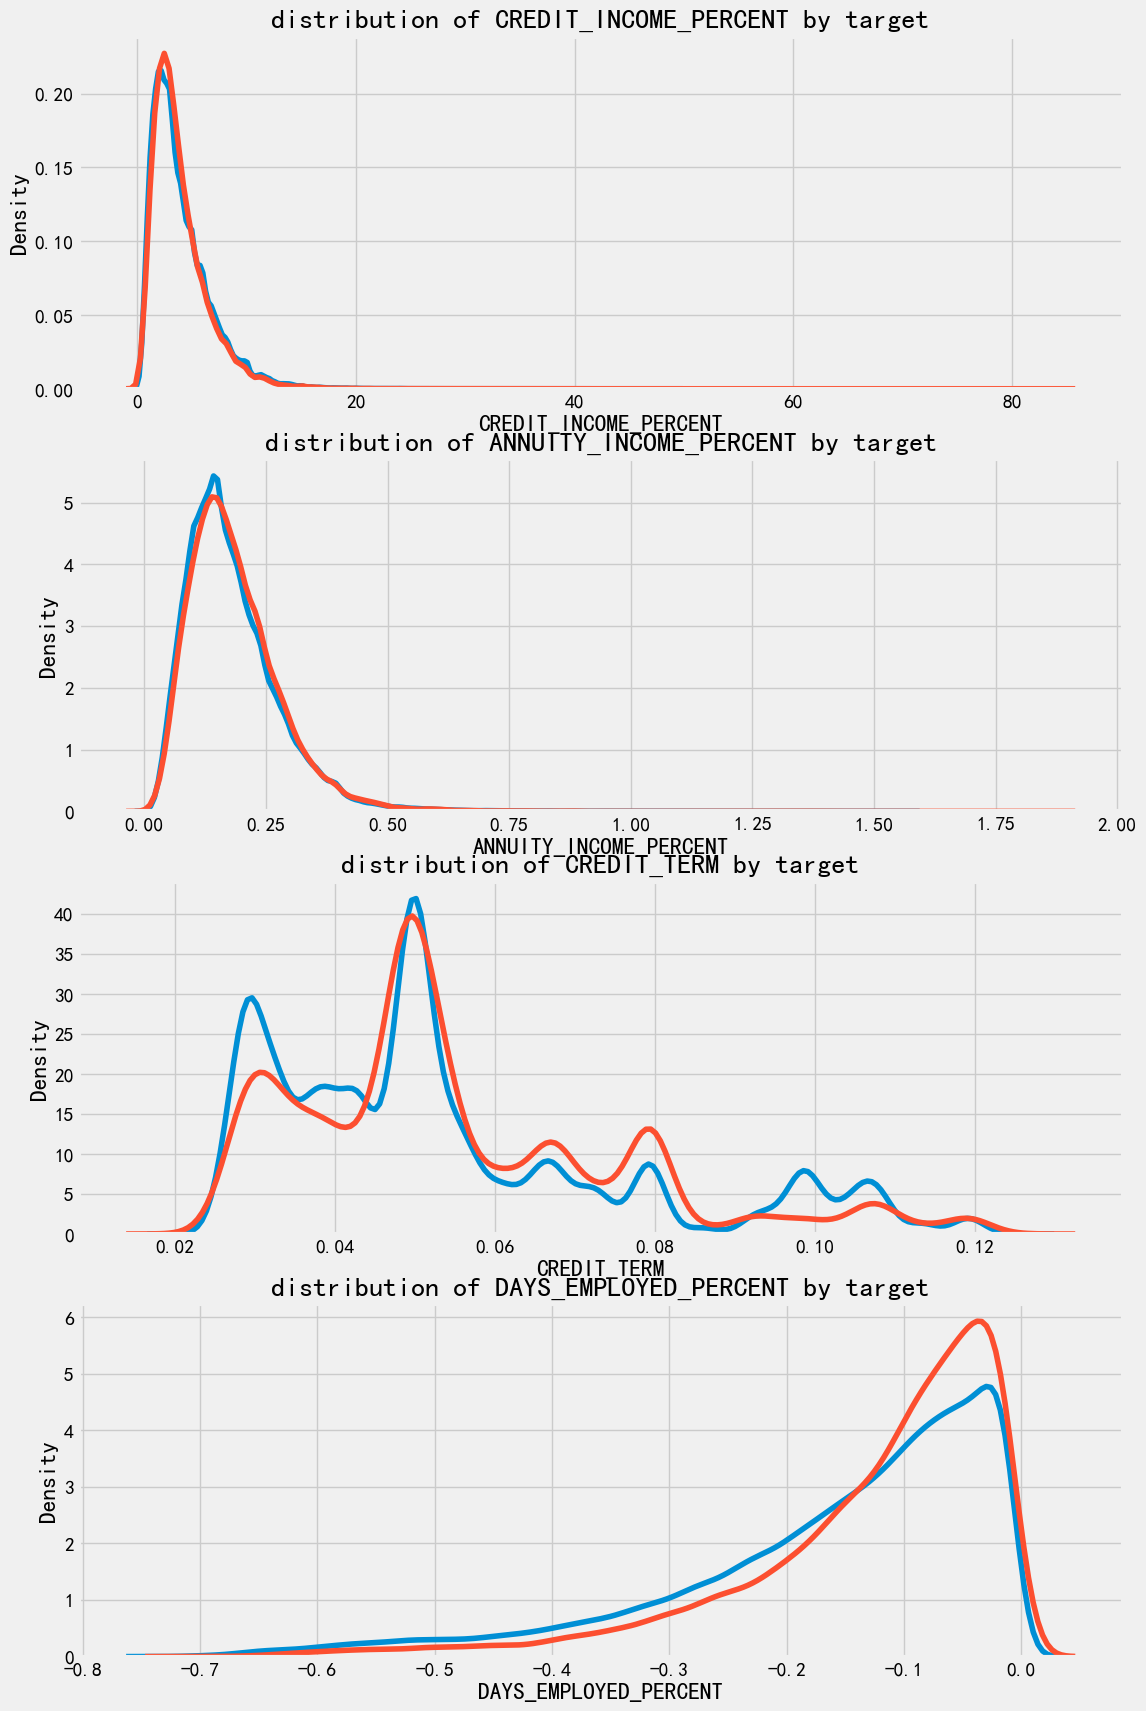

In [157]:
plt.figure(figsize=(12,20))
for i, feature in enumerate(['CREDIT_INCOME_PERCENT', 'ANNUITY_INCOME_PERCENT', 'CREDIT_TERM', 'DAYS_EMPLOYED_PERCENT']):
    plt.subplot(4,1, i+1)
    sns.kdeplot(application_train_domain.loc[application_train_domain['TARGET'] == 0, feature], label = 'target = 0')
    sns.kdeplot(application_train_domain.loc[application_train_domain['TARGET'] == 1, feature], label = 'target = 1')
    plt.title(f'distribution of {feature} by target')

可以看到， 对于每个新特征而言， 违约的人和不违约的没什么区别。 🙌 没感觉他有啥用
就是亲自试试呢~

## baseline

作为baseline：
- 使用了全特征
- 填充缺失值
- 数据归一化，统一量度

In [158]:
print(application_train.shape)
list(application_train.columns)

(307511, 244)


['SK_ID_CURR',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_AVG',
 'YEARS_BUILD_AVG',
 'COMMONAREA_AVG',
 'ELEVATORS_AVG',
 'ENTRANCES_AVG',
 'FLOORSMAX_AVG',
 'FLOORSMIN_AVG',
 'LANDAREA_AVG',
 'LIVINGAPARTMENTS_AVG',
 'LIVINGAREA_AVG',
 'NONLIVINGAPARTMENTS_AVG',
 'NONLIVINGAREA_AVG',
 'APARTMENTS_MODE',
 'BASEMENTAREA_MODE',
 

In [159]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer

train = application_train.copy()
train_labels = train['TARGET']
train = train.drop(columns = ['TARGET'])
test = application_test.copy()


features = list(train.columns)

imputer = SimpleImputer(strategy='median')
scaler = MinMaxScaler(feature_range=(0,1))

imputer.fit(train)
train = imputer.transform(train)
test = imputer.transform(test)

scaler.fit(train)
train = scaler.transform(train)
test = scaler.transform(test)

print('Training data shape: ', train.shape)
print('Testing data shape: ', test.shape)


Training data shape:  (307511, 243)
Testing data shape:  (48744, 243)


### logistic regression

In [160]:
from sklearn.linear_model import LogisticRegression

In [161]:
log_regress_model = LogisticRegression(C=0.001)
log_regress_model.fit(train, train_labels)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.001
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [162]:
log_regress_model_pred = log_regress_model.predict_proba(test)
log_regress_model_pred = log_regress_model_pred[:, 1]

得到了违约的概率

In [163]:

submit = application_test[['SK_ID_CURR']]
submit['TARGET'] = log_regress_model_pred
submit.head()

,SK_ID_CURR,TARGET
0,100001,0.094349
1,100005,0.269978
2,100013,0.069365
3,100028,0.082479
4,100038,0.178499


In [164]:
submit.to_csv('data/log_regress_model_baseline.csv', index = False)

我们得到了 71%得分

### 改进：random forest

In [165]:
from sklearn.ensemble import RandomForestClassifier


In [166]:
random_forest_model = RandomForestClassifier(
    n_estimators = 100, random_state = 50, verbose = 1, n_jobs = -1
)
random_forest_model.fit(train, train_labels)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    7.5s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   26.9s finished


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [167]:
random_forest_model_pred = random_forest_model.predict_proba(test)[:, 1]

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.3s finished


In [168]:
submit = application_test[['SK_ID_CURR']]
submit['TARGET'] = random_forest_model_pred
submit.to_csv('data/random_forest_baseline.csv', index=False)

In [169]:
submit

,SK_ID_CURR,TARGET
0,100001,0.15
1,100005,0.15
2,100013,0.09
3,100028,0.15
4,100038,0.21
...,...,...
48739,456221,0.12
48740,456222,0.16
48741,456223,0.22
48742,456224,0.14


得分68.5

### 改进：random forest with 多项式特征工程

In [170]:
poly_features_names = list(application_train_poly.columns)

In [171]:
application_train_poly.shape

(307511, 278)

In [172]:
imputer = SimpleImputer(strategy='median')
scaler = MinMaxScaler(feature_range=(0,1))

poly_features = imputer.fit_transform(application_train_poly)
poly_features_test = imputer.transform(application_test_poly)

poly_features = scaler.fit_transform(poly_features)
poly_features_test = scaler.transform(poly_features_test)


In [173]:
random_forest_poly = RandomForestClassifier(n_estimators = 100, random_state = 50, verbose = 1, n_jobs = -1)
random_forest_poly.fit(poly_features, train_labels)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   12.6s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   42.9s finished


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [174]:
random_forest_poly_pred = random_forest_poly.predict_proba(poly_features_test)[:, 1]

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


In [175]:
submit = application_test[['SK_ID_CURR']]
submit['TARGET'] = random_forest_poly_pred

submit.to_csv('random_forest_baseline_engineered.csv', index = False)

得分65，特征工程并没有起到作用

### 改进：random forest with 领域知识特征工程

In [176]:
application_train_domain.columns

Index(['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE',
       'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
       ...
       'WALLSMATERIAL_MODE_Stone, brick', 'WALLSMATERIAL_MODE_Wooden',
       'EMERGENCYSTATE_MODE_No', 'EMERGENCYSTATE_MODE_Yes', 'TARGET',
       'DAYS_EMPLOYED_ANOM', 'CREDIT_INCOME_PERCENT', 'ANNUITY_INCOME_PERCENT',
       'CREDIT_TERM', 'DAYS_EMPLOYED_PERCENT'],
      dtype='str', length=248)

In [177]:
application_train_domain = application_train_domain.drop(columns=['TARGET'])

In [178]:
imputer = SimpleImputer(strategy='median')
scaler = MinMaxScaler(feature_range=(0,1))

domain_features = imputer.fit_transform(application_train_domain)
domain_features_test = imputer.transform(application_test_domain)

domain_features = scaler.fit_transform(domain_features)
domain_features_test = scaler.transform(domain_features_test)


In [179]:
random_forest_domain = RandomForestClassifier(n_estimators = 100, random_state = 50, verbose = 1, n_jobs = -1)
random_forest_domain.fit(domain_features, train_labels)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    8.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   29.8s finished


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [180]:
random_forest_domain_pred = random_forest_domain.predict_proba(domain_features_test)[:, 1]

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.2s finished


In [181]:
submit = application_test[['SK_ID_CURR']]
submit['TARGET'] = random_forest_domain_pred

submit.to_csv('random_forest_baseline_domain_engineered.csv', index = False)

得分65， 没什么改变呢

### random forest 模型解释
- 我们之前预期到`EXT_SOURCE`和`DAYS_BIRTH`是最重要的，
- 

In [182]:
feature_importances = random_forest_model.feature_importances_
feature_importances = pd.DataFrame({
    'feature': features,
    'importance':feature_importances
    }
)
feature_importances.sort_values(by='importance', ascending=False)

,feature,importance
29,EXT_SOURCE_2,0.049029
30,EXT_SOURCE_3,0.046400
10,DAYS_ID_PUBLISH,0.031736
7,DAYS_BIRTH,0.031524
9,DAYS_REGISTRATION,0.031100
...,...,...
12,FLAG_MOBIL,0.000000
89,FLAG_DOCUMENT_12,0.000000
87,FLAG_DOCUMENT_10,0.000000
81,FLAG_DOCUMENT_4,0.000000


In [183]:
feature_importances['importance'].sum()

np.float64(0.9999999999999997)

画个倒立直方图看看

Text(0.5, 1.0, 'impotance of features')

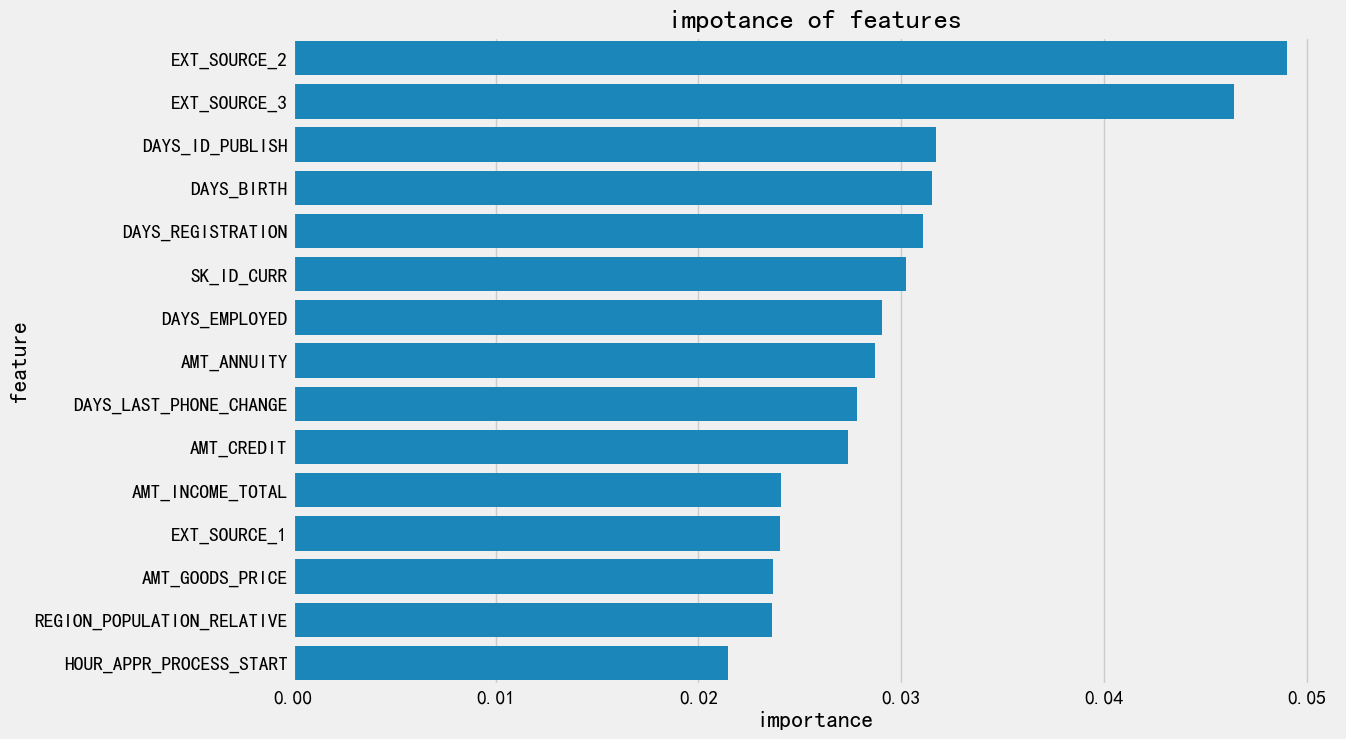

In [184]:
feature_importances_plot = feature_importances.sort_values(by='importance', ascending=False)[:15]
plt.figure(figsize=(12,8))
sns.barplot(
    data = feature_importances_plot,
    x = 'importance',
    y = 'feature'
)
plt.title('impotance of features')

## model

### Adaboost

In [185]:
from sklearn.ensemble import AdaBoostClassifier


In [186]:
print(train.shape)

(307511, 243)


In [187]:
adaboost_model = AdaBoostClassifier(
    n_estimators=100
)
adaboost_model.fit(train, train_labels)

,estimator,None
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [188]:
adaboost_model_pred = adaboost_model.predict(test)

In [189]:
submit = application_test[['SK_ID_CURR']]
submit['TARGET'] = adaboost_model_pred

submit.to_csv('adaboost.csv', index = False)

得分 50

### Gradient boost 

In [190]:
from sklearn.ensemble import GradientBoostingClassifier

In [191]:
print(train.shape)

(307511, 243)


In [195]:
gradient_boost_model = GradientBoostingClassifier(
    n_estimators = 100,
    learning_rate = 0.3
)
gradient_boost_model.fit(train, train_labels)

,loss,'log_loss'
,learning_rate,0.3
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [193]:
gradient_boost_model_pred = gradient_boost_model.predict(test)

In [194]:
submit = application_test[['SK_ID_CURR']]
submit['TARGET'] = gradient_boost_model_pred

submit.to_csv('gradient_boost.csv', index = False)

得分 52分

TODO 为什么随机森林和boost显示出大的区别？
- 随机森林在65分左右
- boost在50分左右

可能是噪声太大了， 随机森林对于噪声影响小，而boost会执着于那些噪声